In [1]:
suppressPackageStartupMessages({
library(gplots)
library(NanoStringNCTools)
library(RColorBrewer)
library(grid)
library(gridExtra)
library(knitr)
library(ggplot2)
library(dplyr)
library(plyr)
library(openxlsx)
# library(limma)
library(DESeq2)
library(lme4)
library(AnnotationDbi)
library(org.Hs.eg.db)
library(clusterProfiler)
library(png)
library(grid)
library(gridExtra)
library(ggforce)
library(tidyverse)
library(GeomxTools)
library(tidyverse)
library(edgeR)
library(aliases2entrez)
library(biomaRt)
HGNC <- update_symbols()
library(stringr)
source('/home/dimitris/Workspace/crc/scripts/geomx_helper_functions.R')
})
load("/home/dimitris/Workspace/crc/data/geomx_crc.RData")
target_demoData$location <- ifelse(target_demoData$location == 'front' ,'border',target_demoData$location)
target_demoData$mucinous <- ifelse(pData(target_demoData)$mucinous == 'true','mucinous','non-mucinous')
cd68_subset <- target_demoData[,pData(target_demoData)$segment == 'CD68']


Warning message:
“package ‘NanoStringNCTools’ was built under R version 4.4.2”
Warning message:
“package ‘Biobase’ was built under R version 4.4.2”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.4.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.4.2”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘knitr’ was built under R version 4.4.3”
Warning message:
“package ‘DESeq2’ was built under R version 4.4.3”
Warning message:
“package ‘IRanges’ was built under R version 4.4.2”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.4.2”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.4.2”
Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.4.2”
Warning message:
“package ‘MatrixGenerics’ was built under R version 4.4.2”
Warning message:
“package ‘matrixStats’ was built under R version 4.4.2”
Warning message:
“package ‘lme4’ was built under R ver

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’



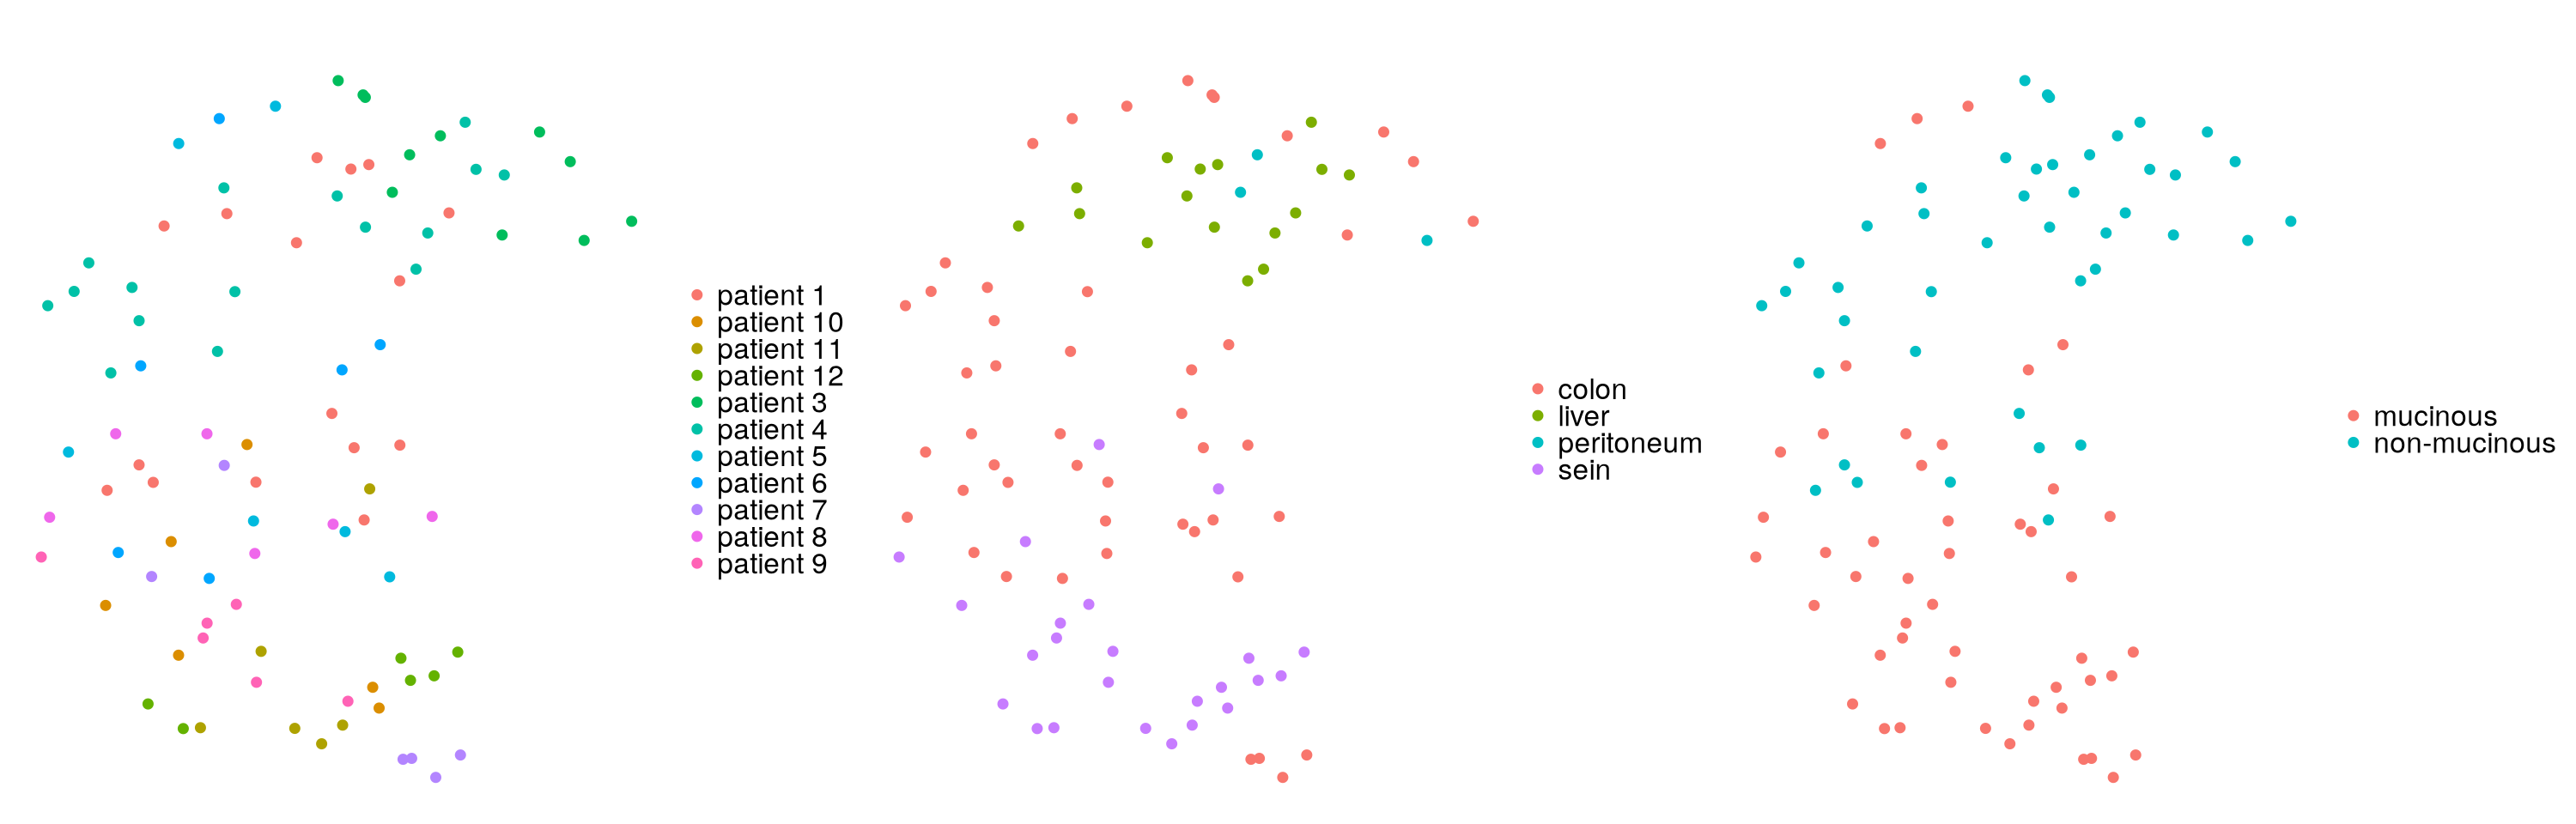

In [2]:
cd68_subset <- run_umap(cd68_subset)
plots <- list()
plots[[1]] <- umap_plot(cd68_subset,"","patient_id")
plots[[2]] <- umap_plot(cd68_subset,"","tissue")
plots[[3]] <- umap_plot(cd68_subset,"","mucinous")
options(repr.plot.width=25, repr.plot.height=8)
grid.arrange(grobs = plots, ncol = 3)

In [3]:
lmm <- function(df,study_column){
        results <- c()
        
        names(pData(df))[names(pData(df))=="slide name"] <- "slide"
        uniq_values = unique(pData(df)[,study_column])
        print(paste("categories of column:",study_column,uniq_values))
        if (length(uniq_values) < 2){
                return(FALSE)
        }
        pData(df)$testRegion <- factor(pData(df)[[study_column]],uniq_values )
        pData(df)[["patient"]] <- factor(pData(df)[["patient_id"]])
        pData(df)[["roi"]] <- factor(pData(df)[["roi"]])
        pData(df)[["location"]] <- factor(pData(df)[["location"]])

        formula = ~ testRegion + (1 | slide)
        
        assayDataElement(object = df, elt = "log_q") <- assayDataApply(df, 2, FUN = log, base = 2, elt = "q_norm")

        print(dim(assayDataElement(df, "log_q") ))
        mixedOutmc <- mixedModelDE(df,
                                   elt = "log_q",
                                   modelFormula = formula,
                                   groupVar = "testRegion",
                                   nCores = 8,
                                   multiCore = TRUE)

        # format results as data.frame
        r_test <- do.call(rbind, mixedOutmc["lsmeans", ])
        tests <- rownames(r_test)
        r_test <- as.data.frame(r_test)
        r_test$Contrast <- tests

        # use lapply in case you have multiple levels of your test factor to
        # correctly associate gene name with it's row in the results table
        r_test$Gene <- unlist(lapply(colnames(mixedOutmc), rep, nrow(mixedOutmc["lsmeans", ][[1]])))
        r_test$FDR <- p.adjust(r_test$`Pr(>|t|)`, method = "fdr")
        r_test <- r_test[, c("Gene", "Contrast", "Estimate", 
                             "Pr(>|t|)", "FDR")]
                results <- rbind(results, r_test)

                kable(subset(head(results,20)), digits = 3,
                      caption = "DE results for Genes of Interest",
                      align = "lc", row.names = FALSE)


                results$Color <- "NS or FC < 0.5"
                results$Color[results$`Pr(>|t|)` < 0.05] <- "P < 0.05"
                results$Color[results$FDR < 0.05] <- "FDR < 0.05"
                results$Color[results$FDR < 0.001] <- "FDR < 0.001"
                results$Color[abs(results$Estimate) < 0.5] <- "NS or FC < 0.5"
                results$Color <- factor(results$Color,
                                        levels = c("NS or FC < 0.5", "P < 0.05",
                                                   "FDR < 0.05", "FDR < 0.001"))
                results$invert_P <- (-log10(results$`Pr(>|t|)`)) * sign(results$Estimate)
                return(results)
}

results <- lmm(cd68_subset,"mucinous")

ERROR: Error in rawToChar(bytes): embedded nul in string: '[1] "categories of column: mucinous non-mucinous"\n[2] "categories of column: mucinous mucinous"    \n[1] 17512    91\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system call\nR_zmq_msg_send errno: 4 strerror: Interrupted system ca

In [34]:
results

Gene,Contrast,Estimate,Pr(>|t|),FDR,Color,invert_P
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>


Warning message in geom_text_repel(data = subset(df, Gene %in% goi1), size = 3, :
“Ignoring unknown parameters: `linewidth`”
Warning message in geom_text_repel(data = subset(df, Gene %in% goi2), size = 3, :
“Ignoring unknown parameters: `linewidth`”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's colour values.”


ERROR: Error in hclust(d, method = method): must have n >= 2 objects to cluster


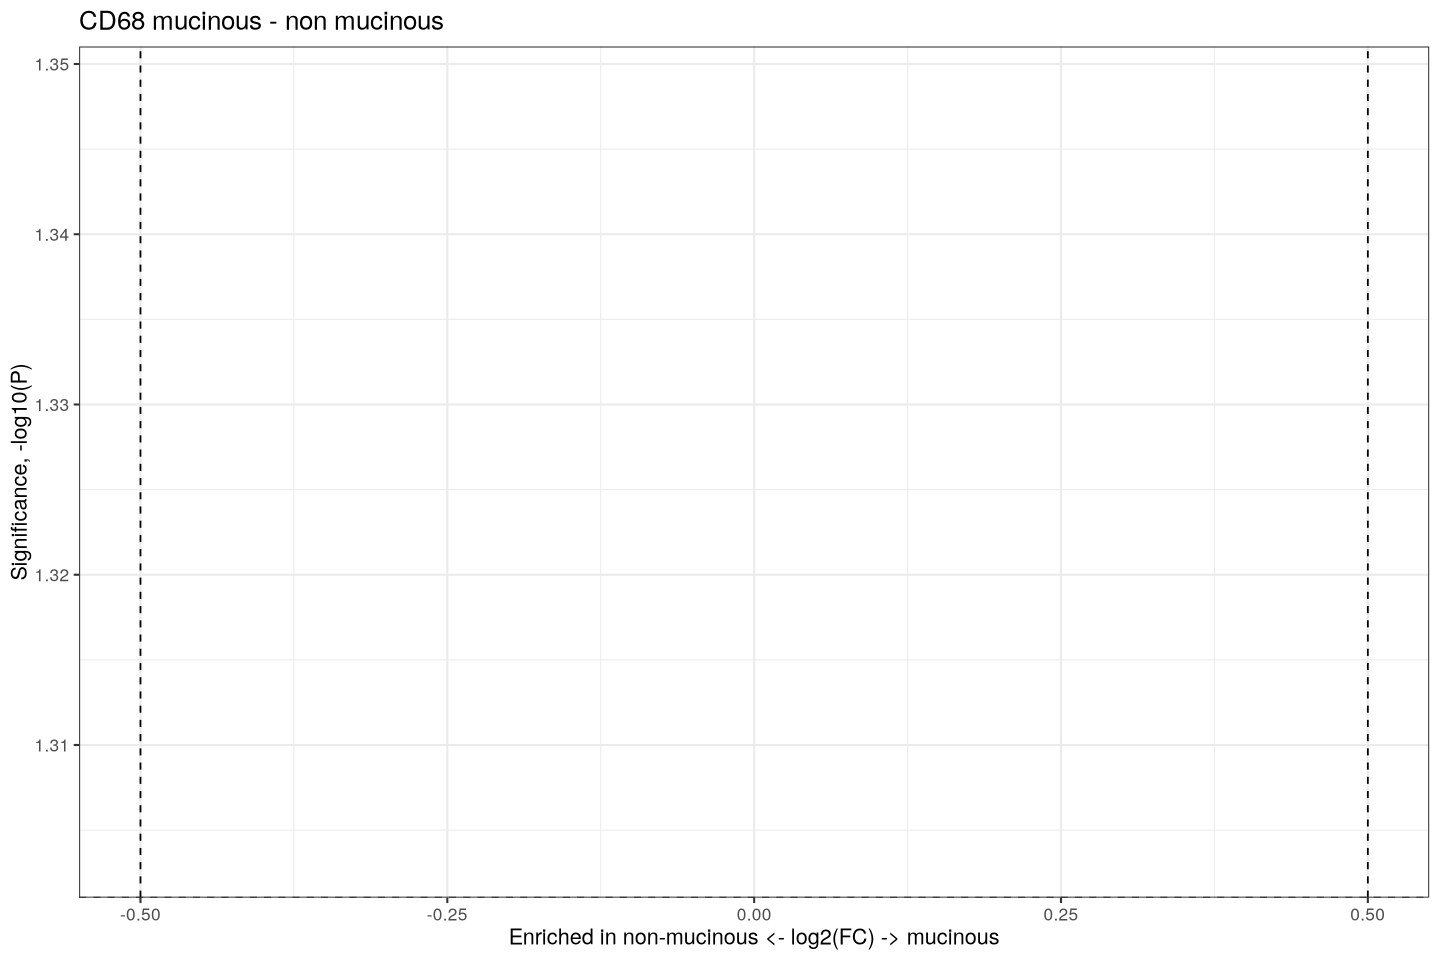

In [33]:
results <- results[order(results$FDR,decreasing = F),]
results <- results[results$Contrast =='mucinous - non-mucinous',]

mucinous_degs <- results[results$Estimate < -0.5 & results$FDR < 0.05,]$Gene
non_mucinous_degs <- results[results$Estimate > 0.5 & results$FDR < 0.05,]$Gene
number_of_genes = 30
positive <- subset(results[order(results$`FDR`, decreasing = FALSE),], `FDR` < 0.05 & Estimate > 0.5 )
extreme_pos <- head(positive,number_of_genes)$Gene
negative <- subset(results[order(results$`FDR`, decreasing = FALSE),], `FDR` < 0.05 & Estimate < -0.5 )
extreme_neg <- head(negative,number_of_genes)$Gene

plots <- list()
options(repr.plot.width=12, repr.plot.height=8)

title <- paste('CD68 mucinous - non mucinous ')
volcano_plot(results,"mucinous - non-mucinous",title,goi1=extreme_pos,goi2=extreme_neg)

options(repr.plot.width=9, repr.plot.height=7)
meta <- pData(cd68_subset)[pData(cd68_subset)$mucinous %in% c('true','false'),]
GOI  <- c(extreme_pos,extreme_neg)
data <- log2(assayDataElement(cd68_subset[GOI,pData(cd68_subset)$mucinous  %in% c('true','false')], elt = "q_norm"))
data <- data[,order(meta$patient_id)]
pheatmap(data,
         scale = "row", 
         show_rownames = T, show_colnames = F,
         border_color = NA,
         cluster_cols = T, cluster_rows = T,  
         #gaps_col = c(9),gaps_row = c(30),
         cutree_cols = 2, cutree_rows = 2,
         treeheight_row =0,treeheight_col = 0,
         breaks = seq(-3, 3, 0.05),
         legend = F, annotation_legend = T, annotation_names_row =T,fontsize_row=6, fontsize=6,
         color = colorRampPalette(c("navy",'white',"red"))(120),
         annotation_col = pData(cd68_subset)[c('mucinous','patient_id','tissue')]
        )

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



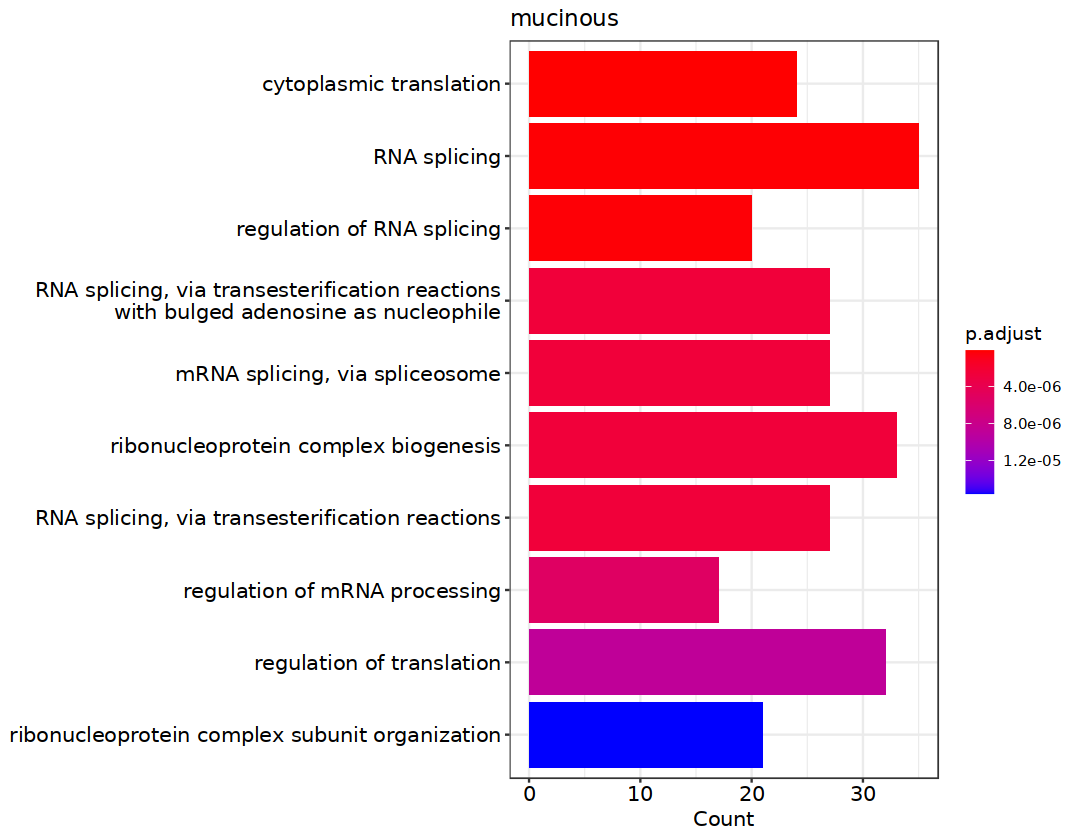

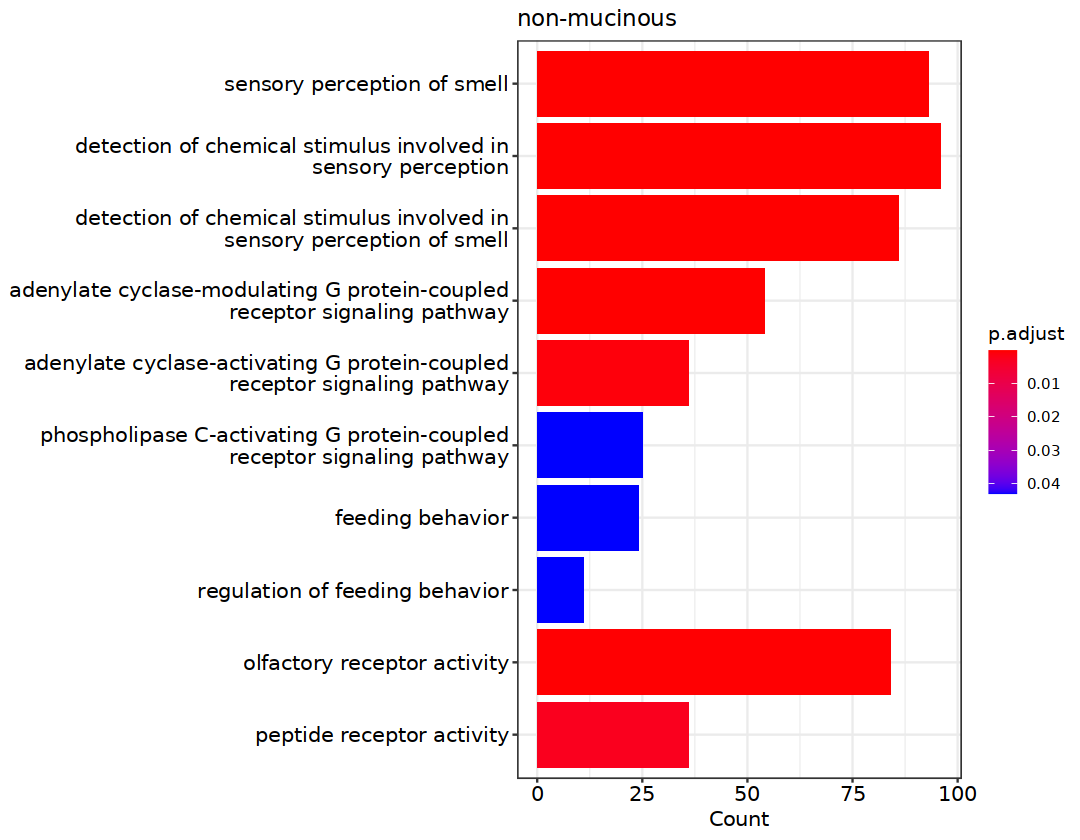

In [7]:
plot_ontology(mucinous_degs,'mucinous')
plot_ontology(non_mucinous_degs,'non-mucinous')

In [5]:
matrix <- assayData(cd68_subset)[["exprs"]]

meta_cd68 <- pData(cd68_subset)
meta_cd68$slide <- as.factor(meta_cd68$`slide name`)
meta_cd68$roi <- as.factor(meta_cd68$roi)
meta_cd68$mucinous <- as.factor(meta_cd68$mucinous)
meta_cd68$patient_id <- as.factor(meta_cd68$patient_id)
meta_cd68$mucinous <- relevel(meta_cd68$mucinous, ref = "mucinous")  # Assuming "false" is your reference level
meta_cd68$tissue <- as.factor(meta_cd68$tissue)

#Group <- factor(paste(meta_cd68$mucinous,sep="."))

y = DGEList(counts = matrix,samples=meta_cd68)
y <- calcNormFactors(y)
design <- model.matrix(~ 0 + tissue + mucinous, data = meta_cd68)
#design <- design[, colSums(design != 0) > 0]
#colnames(design) <- levels(Group)

#qr(design)$rank
#print(ncol(design))

y <- estimateDisp(y,design)

    #y <- estimateGLMCommonDisp(y, design)
    #y <- estimateGLMTrendedDisp(y, design)
    #y <- estimateGLMTagwiseDisp(y, design)

print(y$common.dispersion)
fit <- glmQLFit(y,design,robust=T)
print(colnames(fit))
#kable(y$samples)

[1] 0.06769513
[1] "tissuecolon"          "tissueliver"          "tissueperitoneum"    
[4] "tissuesein"           "mucinousnon-mucinous"


In [6]:
table(meta$mucinous)

ERROR: Error: object 'meta' not found


In [ ]:
qlf <- glmQLFTest(fit,contrast=c(0,0,0,0,1))

summary(decideTests(qlf))
topTags(qlf,n=10)

print(unique(y$samples$group))

results <- topTags(qlf,n=Inf)$table
results$FDR <- p.adjust(results$PValue, method="BH")
mucinous_degs <-rownames(results[results$logFC > 0.5 & results$FDR < 0.05,])
non_mucinous_degs <- rownames(results[results$logFC < -0.5 & results$FDR < 0.05,])
extremes <- extreme_genes_edger(results,20)

volcano_edger(results,left = 'non_mucinous',right = 'mucinous',title = 'CD68: mucinous - non-mucinous',extremes$pos,extremes$neg)

GOI <- c(extremes$pos,extremes$neg)
logcpm <-cpm(y,log=TRUE)
data <- logcpm[GOI,]
pheatmap(data,
         scale = "row", 
         show_rownames = T, show_colnames = F,
         border_color = NA,
         cluster_cols = T, cluster_rows = T,  
         #gaps_col = c(9),gaps_row = c(30),
         cutree_cols = 2, cutree_rows = 2,
         treeheight_row =0,treeheight_col = 0,
         breaks = seq(-3, 3, 0.05),
         legend = F, annotation_legend = T, annotation_names_row =T,fontsize_row=6, fontsize=6,
         color = colorRampPalette(c("navy",'white',"red"))(120),
         annotation_col = pData(cd68_subset)[c('mucinous','patient_id','tissue')]
        )
options(repr.plot.width=NULL, repr.plot.height=NULL)

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



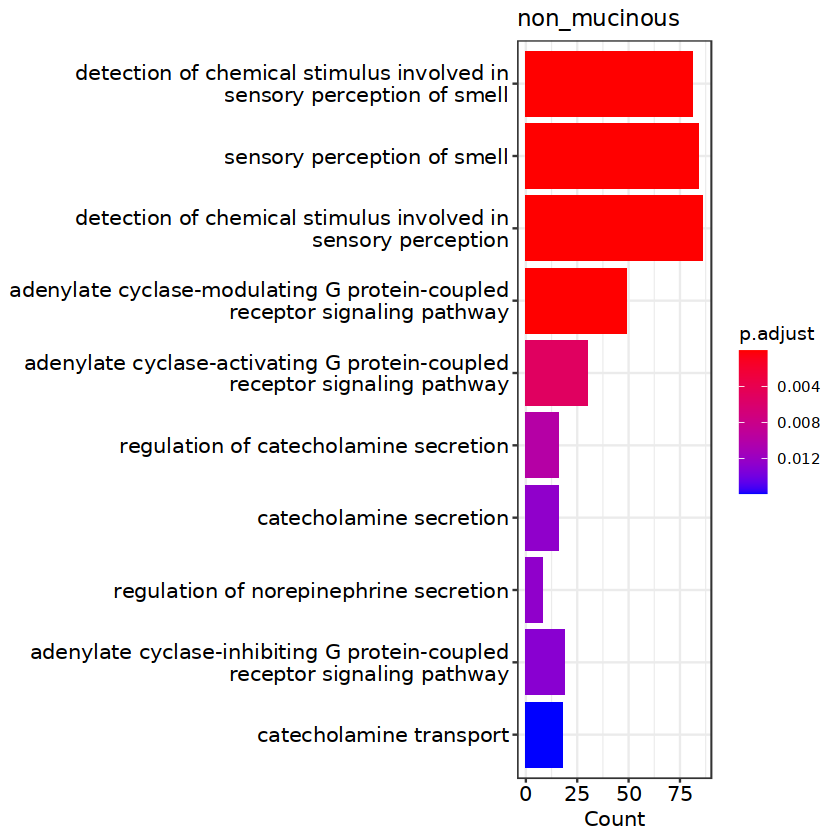

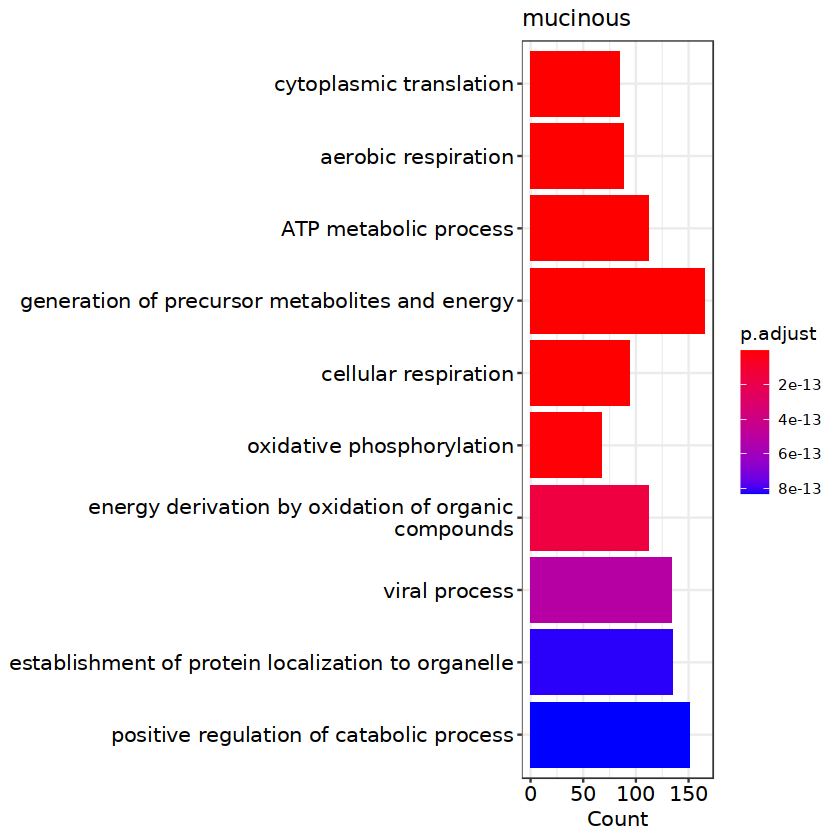

In [11]:
plot_ontology(non_mucinous_degs,'non_mucinous')
plot_ontology(mucinous_degs,'mucinous')